Задание 1
Минимизация гладкой функции

1.	Рассмотрим функцию: f(x) = sin(x / 5) exp(x / 10) + 5 exp(-x / 2) на промежутке [1, 30]

2.	Постройте график функции.

3.	Попробуйте найти минимум, используя стандартные параметры в функции scipy.optimize.minimize (т.е. задав только функцию и начальное приближение). Попробуйте менять начальное приближение и изучить, меняется ли результат.

4.	Запишите выводы.

5.	Укажите в scipy.optimize.minimize в качестве метода BFGS (один из самых точных в большинстве случаев градиентных методов оптимизации), запустите из начального приближения x=2. Градиент функции при этом указывать не нужно – он будет оценен численно.

6.	Выведите полученное значение функции в точке минимума с точностью до 2 знака после запятой.

7.	Измените начальное приближение на x=30. Выведите значение функции в точке минимума  с точностью до 2 знака после запятой.

In [14]:
# Импорт
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [19]:
#функция на [1, 30]
def f_scalar(t):
    t = np.asarray(t).item()
    return float(np.sin(t/5.0)*np.exp(t/10.0) + 5*np.exp(-t/2.0))

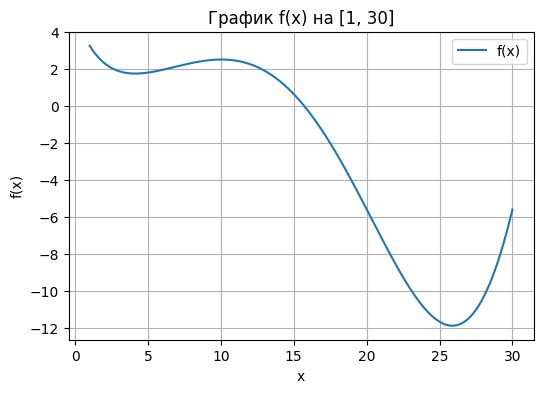

In [20]:
#график функции на [1, 30]
xs = np.linspace(1, 30, 800)
ys = f(xs)

plt.figure(figsize=(6,4))
plt.plot(xs, ys, label="f(x)")
plt.grid(True); plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("График f(x) на [1, 30]"); plt.legend(); plt.show()

In [21]:
# поиск минимума: стандартные параметры, разные начальные x0 (номер 3-4)
def run_min(x0, method=None):
    res = minimize(f_scalar, x0=float(x0), method=method)
    x_star = np.asarray(res.x).item()
    f_star = f_scalar(x_star)
    return {
        "method": method or "default",
        "x0": float(x0),
        "x*": x_star,
        "f(x*)": f_star,
        "nit": res.nit,
        "success": bool(res.success),
    }
inits = [1, 2, 5, 10, 15, 20, 25]
#inits = []
results_std = [run_min(x0) for x0 in inits]
results_std

[{'method': 'default',
  'x0': 1.0,
  'x*': 4.136286972718686,
  'f(x*)': 1.745268290332219,
  'nit': 7,
  'success': True},
 {'method': 'default',
  'x0': 2.0,
  'x*': 4.136276281772837,
  'f(x*)': 1.7452682903447336,
  'nit': 6,
  'success': True},
 {'method': 'default',
  'x0': 5.0,
  'x*': 4.136288322666482,
  'f(x*)': 1.745268290331984,
  'nit': 6,
  'success': True},
 {'method': 'default',
  'x0': 10.0,
  'x*': 4.1363002278699295,
  'f(x*)': 1.7452682903429801,
  'nit': 3,
  'success': True},
 {'method': 'default',
  'x0': 15.0,
  'x*': 24.677661105507816,
  'f(x*)': -11.503580766270698,
  'nit': 1,
  'success': False},
 {'method': 'default',
  'x0': 20.0,
  'x*': 25.880187419164756,
  'f(x*)': -11.898894665971952,
  'nit': 4,
  'success': True},
 {'method': 'default',
  'x0': 25.0,
  'x*': 25.880185915711404,
  'f(x*)': -11.89889466596626,
  'nit': 4,
  'success': True}]

In [22]:
# явно указать метод BFGS, старт x0=2 (градиент не задаём — он оценится численно)(5)
res_bfgs_2 = run_min(2, method="BFGS")
res_bfgs_2

{'method': 'BFGS',
 'x0': 2.0,
 'x*': 4.136276281772837,
 'f(x*)': 1.7452682903447336,
 'nit': 6,
 'success': True}

In [23]:
# значение функции в точке минимума с точностью до 2 знаков
print(f"f(x*) при x0=2, BFGS = {res_bfgs_2['f(x*)']:.2f}")

f(x*) при x0=2, BFGS = 1.75


In [24]:
#старт x0=30, метод BFGS. Значение функции в минимуме с точностью до 2 знаков
res_bfgs_30 = run_min(30, method="BFGS")
print(f"f(x*) при x0=30, BFGS = {res_bfgs_30['f(x*)']:.2f}")

f(x*) при x0=30, BFGS = -11.90


In [25]:
#доп: сравнение результатов по разным x0 (стандартные настройки)
import pandas as pd
df = pd.DataFrame(results_std + [res_bfgs_2, res_bfgs_30])
df[["method","x0","x*","f(x*)","nit","success"]]

,method,x0,x*,f(x*),nit,success
0,default,1.0,4.136287,1.745268,7,True
1,default,2.0,4.136276,1.745268,6,True
2,default,5.0,4.136288,1.745268,6,True
3,default,10.0,4.136300,1.745268,3,True
4,default,15.0,24.677661,-11.503581,1,False
5,default,20.0,25.880187,-11.898895,4,True
6,default,25.0,25.880186,-11.898895,4,True
7,BFGS,2.0,4.136276,1.745268,6,True
8,BFGS,30.0,25.880193,-11.898895,6,True


Задание 2 Глобальная оптимизация

Попробуем применить к той же функции f(x) метод глобальной оптимизации — дифференциальную эволюцию.

1.	Изучите документацию по использованию функции scipy.optimize.differential_evolution.

2.	Обратите внимание, что границы значений аргументов функции представляют собой список кортежей (list, в который помещены объекты типа tuple). Даже если у вас функция одного аргумента, возьмите границы его значений в квадратные скобки, чтобы передавать в этом параметре список из одного кортежа, т.к. в реализации scipy.optimize.differential_evolution длина этого списка используется чтобы определить количество аргументов функции.

3.	Запустите поиск минимума функции f(x) с помощью дифференциальной эволюции на промежутке [1, 30]. Полученное значение функции в точке минимума запишите с точностью до второго знака после запятой. 

4.	 Сделайте вывод.

5.	Сравните количество итераций, потребовавшихся BFGS для нахождения минимума при хорошем начальном приближении, с количеством итераций, потребовавшихся дифференциальной эволюции. 


In [26]:
# Импорт
import numpy as np
from scipy.optimize import differential_evolution, minimize

def f_scalar(t: float) -> float:
    t = np.asarray(t).item()
    return float(np.sin(t/5.0)*np.exp(t/10.0) + 5*np.exp(-t/2.0))

In [27]:
# 1) Глобальная оптимизация: дифференциальная эволюция на [1, 30]
# bounds — список кортежей даже для 1D
bounds = [(1.0, 30.0)]

# objective должен принимать вектор; извлекаем x = v[0]
obj = lambda v: f_scalar(np.asarray(v)[0])

res_de = differential_evolution(obj, bounds=bounds, seed=42)
x_de  = np.asarray(res_de.x).item()
f_de  = float(res_de.fun)

print(f"DE: x*={x_de:.5f}, f(x*)={f_de:.2f}, nit={res_de.nit}, nfev={res_de.nfev}, success={res_de.success}")


DE: x*=25.88019, f(x*)=-11.90, nit=4, nfev=81, success=True


In [28]:
# 2) Сравнение с локальной BFGS при «хорошем» старте (x0=30)
res_bfgs = minimize(f_scalar, x0=30.0, method="BFGS")
x_bfgs = np.asarray(res_bfgs.x).item()
f_bfgs = f_scalar(x_bfgs)

print(f"BFGS: x*={x_bfgs:.5f}, f(x*)={f_bfgs:.2f}, nit={res_bfgs.nit}, nfev={res_bfgs.nfev}, success={res_bfgs.success}")


BFGS: x*=25.88019, f(x*)=-11.90, nit=6, nfev=14, success=True


Задача 3. Минимизация негладкой функции

1. Теперь рассмотрим функцию h(x) = int(f(x)) на отрезке [1, 30], т.е. теперь каждое значение f(x) приводится к типу int и функция принимает только целые значения.

2. Такая функция будет негладкой и даже разрывной, а ее график будет иметь ступенчатый вид. Убедитесь в этом, построив график h(x) с помощью matplotlib.

3. Найти минимум функции h(x) с помощью BFGS, взяв в качестве начального приближения x=30. Запишите ответ.

4. Найти минимум h(x) на отрезке [1, 30] с помощью дифференциальной эволюции. Запишите ответ.

5. Сделайте выводы о применении методов минимизации.
